<a href="https://colab.research.google.com/github/nabinjoshi54/lis5693/blob/main/lab-7/Lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lab7: Sentiment Analysis

In this lab, I am using the BBC News dataset, as asiigned by professor Lamba, to perform sentiment analysis. The goal of this lab work is to clean and preprocess the text, generate sentiment polarity scores, merge those scores back into the original dataset, and visualize the results using different graphing libraries.

Importing Required Libraries:

First, I will import the libraries needed for data handling, text cleaning, sentiment analysis, and visualization. I also download the VADER lexicon, which is required for the sentiment analyzer.

In [14]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

Loading the Dataset:

I am using the raw link BBC News dataset assigned to my group. Since the file is tab-separated, I use `sep='\t'` while reading it. After loading the data, I will inspect the first few rows and confirm the column names.

In [15]:
url = "https://raw.githubusercontent.com/nabinjoshi54/lis5693/refs/heads/main/lab-7/bbc-news-data.csv"

df = pd.read_csv(url, sep="\t")

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Dataset shape: (2225, 4)
Columns: ['category', 'filename', 'title', 'content']


,category,filename,title,content
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...


Understanding the Dataset:

After loading the dataset, I checked the available columns. The BBC News dataset contains the following column such as category, filename, title, and contetnt.
For this lab especially, I selected 'content' as the text field. This is because it contains the full article text, which provides more information for sentiment analysis. If I use the title only, it will not give more context.

Task_1:
In this task, I identify the text field, clean the text, generate sentiment scores. After this I will merge those scores with the original dataset, and visualize the results.

Select the Text Field:
As I have already mentioned, the text field for my dataset is content. To prepare for sentiment analysis, I create a smaller dataframe containing the article category, filename, and content. I include both category and filename because filename values can repeat across categories, so using both ensures a correct merge later.

In [16]:
df_subset = df[['category', 'filename', 'content']].copy()
df_subset.head()

,category,filename,content
0,business,001.txt,Quarterly profits at US media giant TimeWarne...
1,business,002.txt,The dollar has hit its highest level against ...
2,business,003.txt,The owners of embattled Russian oil giant Yuk...
3,business,004.txt,British Airways has blamed high fuel prices f...
4,business,005.txt,Shares in UK drinks and food firm Allied Dome...


Cleaning and Preprocessing the Text:
Before running sentiment analysis, it is really important to clean the dataset to make it ready for further analysis. Therefore, I clean the text to make it more consistent. I remove punctuation and special characters, convert all text to lowercase, and remove extra spaces.


In [17]:
df_subset['content_clean'] = (
    df_subset['content']
    .fillna('')
    .str.replace(r'[^a-zA-Z\s]', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
    .str.lower()
)

df_subset[['filename', 'content_clean']].head()

,filename,content_clean
0,001.txt,quarterly profits at us media giant timewarner...
1,002.txt,the dollar has hit its highest level against t...
2,003.txt,the owners of embattled russian oil giant yuko...
3,004.txt,british airways has blamed high fuel prices fo...
4,005.txt,shares in uk drinks and food firm allied domec...


Generateing Sentiment Scores:
I will use the VADER sentiment analyzer from NLTK. VADER returns four sentiment measures: 'neg' for negative sentiment,'neu' for neutral sentiment, 'pos' for positive sentiment, 'compound' for the overall sentiment score. The 'compound' score ranges from -1 to +1 and is commonly used as the main sentiment polarity score.

In [18]:
sid = SentimentIntensityAnalyzer()

scores_list = []

for _, row in df_subset.iterrows():
    scores = sid.polarity_scores(row['content_clean'])
    scores_list.append({
    'category': row['category'],
    'filename': row['filename'],
    'sentiment_score': scores['compound'],
    'neg': scores['neg'],
    'neu': scores['neu'],
    'pos': scores['pos']
})

sentiment_df = pd.DataFrame(scores_list)
sentiment_df.head()

,category,filename,sentiment_score,neg,neu,pos
0,business,001.txt,0.9956,0.035,0.803,0.162
1,business,002.txt,0.9207,0.050,0.866,0.084
2,business,003.txt,-0.8500,0.066,0.896,0.038
3,business,004.txt,0.9841,0.051,0.824,0.126
4,business,005.txt,0.6652,0.047,0.882,0.071


Merge Sentiment Scores with the Original Dataset:
To combine the sentiment scores with the original dataset, I use both cateory and filename as the common columns. I chose both columns because filename alone is not unique across the dataset. Using both ensures that each sentiment score is matched correctly with its corresponding article and avoids duplicate rows.

In [19]:
df_output = pd.merge(df, sentiment_df, on=['category', 'filename'], how='inner')

print("Merged dataset shape:", df_output.shape)
df_output.head()

Merged dataset shape: (2225, 8)


,category,filename,title,content,sentiment_score,neg,neu,pos
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...,0.9956,0.035,0.803,0.162
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...,0.9207,0.050,0.866,0.084
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...,-0.8500,0.066,0.896,0.038
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...,0.9841,0.051,0.824,0.126
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...,0.6652,0.047,0.882,0.071


Describe the Sentiment Polarity Results:
I will use the describe() method on the sentiment_score column to better understnad the sentiment output. This provides summary statistics such as the count, mean, standard deviation, minimum, quartiles, and maximum. These values help me understand whether the articles are mostly neutral, slightly positive, or slightly negative overall.

In [20]:
df_output[['sentiment_score']].describe()

,sentiment_score
count,2225.000000
mean,0.403981
std,0.796454
min,-0.999900
25%,-0.447200
50%,0.925900
75%,0.984600
max,1.000000


Brief Explanation of the describe() Results:

The summary statistics show that sentiment scores vary widely across the BBC News articles. The dataset includes both strongly negative and strongly positive values, while many articles fall toward the positive range. The mean sentiment score is above zero, which suggests that the dataset leans somewhat positive overall. At the same time, the wide range between the minimum and maximum values shows that different articles have different tones depending on the topic being reported.

Create Sentiment Labels:

To make the results easier to interpret, I classify the compound sentiment score into three labels: positive, neutral, negative. This gives a simpler way to summarize the sentiment of each article.

In [21]:
def label_sentiment(score):
    if score > 0.05:
        return "positive"
    elif score < -0.05:
        return "negative"
    else:
        return "neutral"

df_output['sentiment_label'] = df_output['sentiment_score'].apply(label_sentiment)

df_output[['filename', 'sentiment_score', 'sentiment_label']].head()

,filename,sentiment_score,sentiment_label
0,001.txt,0.9956,positive
1,002.txt,0.9207,positive
2,003.txt,-0.8500,negative
3,004.txt,0.9841,positive
4,005.txt,0.6652,positive


Visualization 1: Average Sentiment by Category Using Matplotlib

I am using Matplotlib to create a bar chart showing the average sentiment score for each BBC News category. This graph helps compare how sentiment changes across topics such as business, entertainment, politics, sport, and tech.

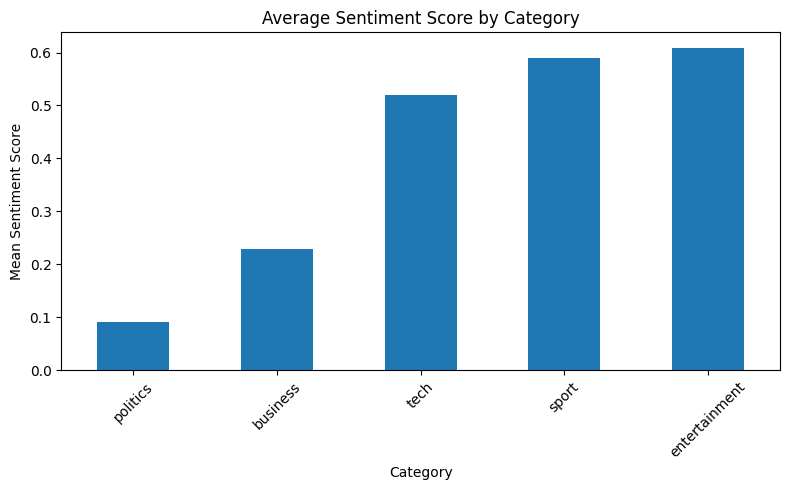

In [22]:
category_mean = df_output.groupby('category')['sentiment_score'].mean().sort_values()

plt.figure(figsize=(8, 5))
category_mean.plot(kind='bar')
plt.title('Average Sentiment Score by Category')
plt.xlabel('Category')
plt.ylabel('Mean Sentiment Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The bar chart shows the average sentiment score for each category. After correcting the merge, the results provide a more accurate comparison across categories. The averages are relatively close, which suggests that BBC News articles tend to have a similar tone across topics. However, small differences between categories may reflect differences in subject matter and reporting style.

Visualization 2: Sentiment Distribution by Category Using Seaborn

This time, I will use Seaborn to create a boxplot of sentiment scores by category. Unlike the bar chart, the boxplot shows the spread and variation of sentiment scores within each category. This helps me see whether some categories have a wider range of emotional tone than others.

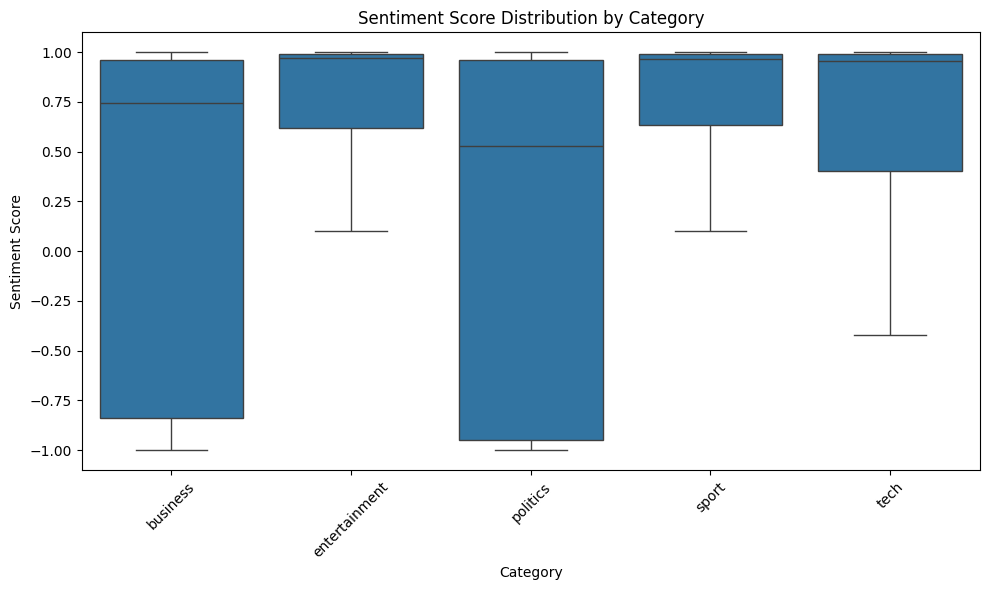

In [23]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_output, x='category', y='sentiment_score', showfliers=False)
plt.title('Sentiment Score Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Sentiment Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The boxplot shows the distribution of sentiment scores within each category. It reveals that each category contains a range of sentiment values rather than a single fixed tone. This means that even within the same category, articles can vary from negative to positive depending on the content.

Additional Visualization: Count of Sentiment Labels:
I will also create below a simple count plot to show how many articles are classified as positive, neutral, or negative. This gives a quick overall summary of the dataset's sentiment distribution.

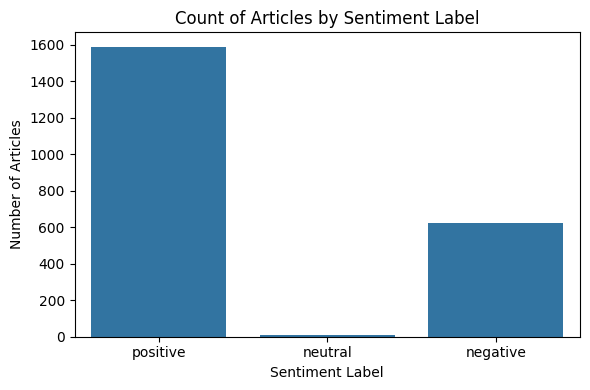

In [24]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_output, x='sentiment_label', order=['positive', 'neutral', 'negative'])
plt.title('Count of Articles by Sentiment Label')
plt.xlabel('Sentiment Label')
plt.ylabel('Number of Articles')
plt.tight_layout()
plt.show()

This plot shows the number of articles classified as positive, neutral, and negative. Most articles are labeled as positive, followed by negative, while only a small number are neutral. This suggests that the VADER sentiment model tends to assign slightly positive scores even to neutral news articles, which is a known limitation when analyzing formal text.

In [25]:
df_output.to_csv("lab7_bbc_sentiment_output.csv", index=False)
print("Saved as lab7_bbc_sentiment_output.csv")

Saved as lab7_bbc_sentiment_output.csv


Reflection:

Overall, this lab went well because I was able to load the dataset from GitHub, preprocess the text, generate sentiment scores, and visualize the results. One important thing I learned is the importance of choosing correct merge columns when combining datasets.

Initially, I used only filename for merging, which created duplicate rows because filenames were repeated across categories. I fixed this by merging using both category and filename, which produced the correct output.

Another challenge is that sentiment analysis does not always fully capture the meaning of formal news articles. Since BBC articles are written in a neutral tone, the model sometimes assigns slightly positive sentiment even when the content is factual.

In my future research and professional work, sentiment analysis can be useful for analyzing large text datasets such as news, survey responses, or online discussions. However, it should always be combined with human interpretation for better understanding.